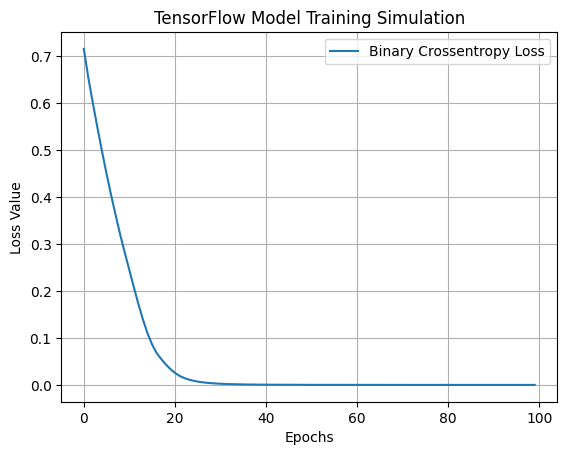

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Prediction Probability: 0.9999


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import BinaryCrossentropy

# 1. Feature Scaling

X = np.array([[0.1, 0.2], [0.2, 0.4], [0.8, 0.9], [0.9, 0.7]], dtype=np.float32)
y = np.array([0, 0, 1, 1], dtype=np.float32)

# 2. Model Architecture
model = Sequential(
    [
        Dense(units=4, activation="relu", name="hidden_layer"), # ReLU
        Dense(
            units=1, activation="linear", name="output_layer"
        ),  # Logits
    ]
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss=BinaryCrossentropy(from_logits=True),  # Numerically Stable
)

history = model.fit(X, y, epochs=100, verbose=0)

plt.plot(history.history["loss"], label="Binary Crossentropy Loss")
plt.title("TensorFlow Model Training Simulation")
plt.xlabel("Epochs")
plt.ylabel("Loss Value")
plt.grid(True)
plt.legend()
plt.show()

logits = model.predict(np.array([[0.85, 0.8]]))
probability = tf.nn.sigmoid(logits).numpy()
print(f"Prediction Probability: {probability[0][0]:.4f}")
